# 🌸 DecodeLabs — Project 2: Data Classification Using AI
**Industrial Training Kit | Batch 2026**

---

### 📌 What you will do in this notebook:
1. Load the Iris dataset
2. Explore & visualise the data
3. Scale features
4. Split into Train / Test sets
5. Find the best K using the Elbow Method
6. Train a KNN model
7. Evaluate with Confusion Matrix & F1 Score


## ⚙️ Step 0 — Install & Import Libraries
Run this cell first. All libraries come pre-installed in Jupyter.

In [2]:
# If any library is missing, uncomment and run:
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📦 Step 1 — Load the Dataset

The **Iris dataset** is the classic benchmark for classification:
- **150 samples** (50 per class — balanced)
- **3 classes**: Setosa, Versicolor, Virginica
- **4 features**: Sepal Length, Sepal Width, Petal Length, Petal Width

In [3]:
# Load dataset
iris = load_iris()

# Create a readable DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print('Dataset shape:', df.shape)
print('Classes:', list(iris.target_names))
print()
df.head(10)

Dataset shape: (150, 5)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
# Basic statistics
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


---
## 📊 Step 2 — Visualise the Data

C:\Users\praka\AppData\Local\Temp\ipykernel_12976\2581724183.py:38: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\praka\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


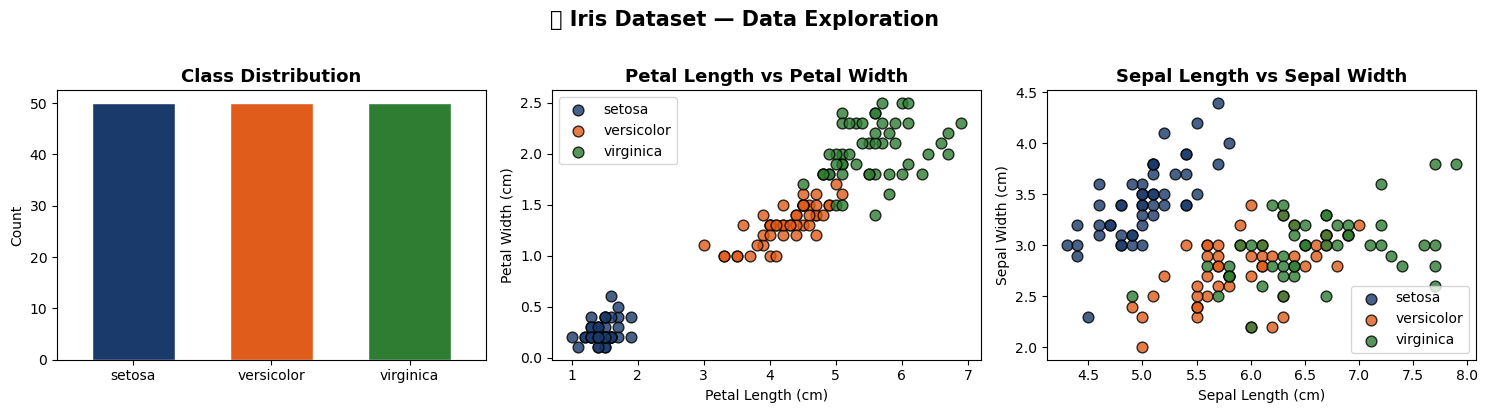

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#1a3a6b', '#e05c1a', '#2e7d32']

# Plot 1 — Class Distribution
df['species'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.6
)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2 — Petal Length vs Petal Width (best separating features)
for i, (name, color) in enumerate(zip(iris.target_names, colors)):
    mask = iris.target == i
    axes[1].scatter(
        iris.data[mask, 2], iris.data[mask, 3],
        label=name, color=color, edgecolors='k', s=60, alpha=0.8
    )
axes[1].set_title('Petal Length vs Petal Width', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()

# Plot 3 — Sepal Length vs Sepal Width
for i, (name, color) in enumerate(zip(iris.target_names, colors)):
    mask = iris.target == i
    axes[2].scatter(
        iris.data[mask, 0], iris.data[mask, 1],
        label=name, color=color, edgecolors='k', s=60, alpha=0.8
    )
axes[2].set_title('Sepal Length vs Sepal Width', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Sepal Length (cm)')
axes[2].set_ylabel('Sepal Width (cm)')
axes[2].legend()

plt.suptitle('🌸 Iris Dataset — Data Exploration', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

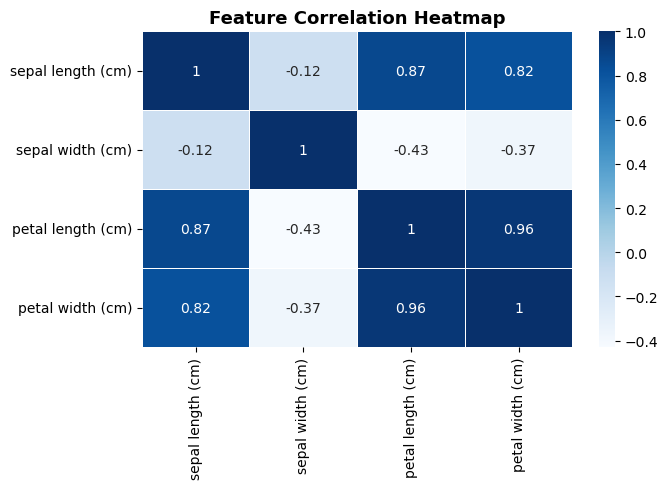

In [6]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    df.drop('species', axis=1).corr().round(2),
    annot=True, cmap='Blues', linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✂️ Step 3 — Train / Test Split

- **80%** → Training set (pattern recognition)
- **20%** → Test set (locked for validation)
- **shuffle=True** → removes order bias

In [9]:
X = iris.data   # features
y = iris.target  # labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducibility
    shuffle=True         # remove order bias
)

print(f'✅ Training samples : {len(X_train)}  (80%)')
print(f'✅ Testing samples  : {len(X_test)}   (20%)')

✅ Training samples : 120  (80%)
✅ Testing samples  : 30   (20%)


---
## ⚖️ Step 4 — Feature Scaling (The Gatekeeper Rule)

KNN uses **distance** to find neighbours.  
Without scaling, a feature with a large range (e.g. 0–1000) will **dominate** over one with a small range (e.g. 0–1).

`StandardScaler` → **Mean = 0, Variance = 1** for every feature.

In [10]:
scaler = StandardScaler()

# IMPORTANT: fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)       # no fit here!

print(f'Before scaling — Mean: {X_train.mean():.3f} | Std: {X_train.std():.3f}')
print(f'After  scaling — Mean: {X_train_scaled.mean():.3f} | Std: {X_train_scaled.std():.3f}')
print('✅ Scaling applied: Mean≈0, Variance≈1')

Before scaling — Mean: 3.445 | Std: 1.963
After  scaling — Mean: -0.000 | Std: 1.000
✅ Scaling applied: Mean≈0, Variance≈1


---
## 🔍 Step 5 — Find the Best K (Elbow Method)

- **K=1** → overfitting (too sensitive to noise)
- **K=100** → underfitting (too generic)
- **The Elbow** → the K where error rate is lowest

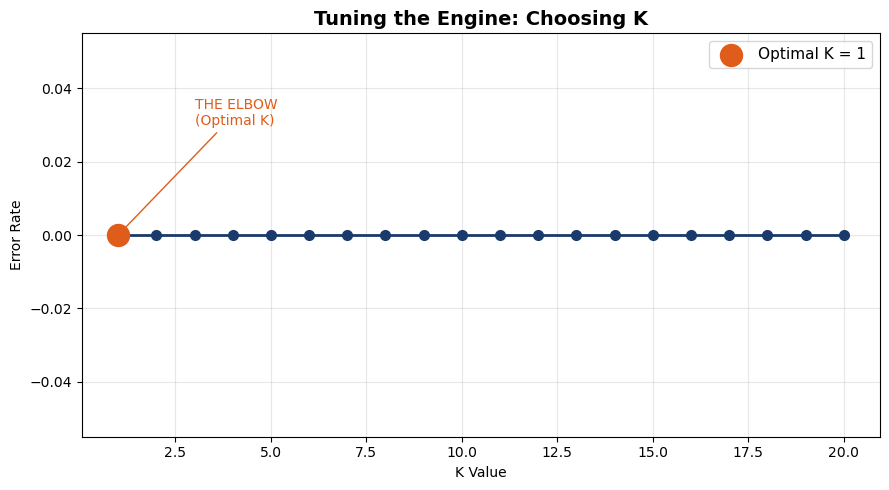

✅ Optimal K = 1  (error rate: 0.0000)


In [11]:
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, preds))

optimal_k = list(k_range)[np.argmin(error_rates)]

# Plot elbow curve
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), error_rates, marker='o', color='#1a3a6b',
         linewidth=2, markersize=7)
plt.scatter(optimal_k, min(error_rates), s=250, color='#e05c1a',
            zorder=5, label=f'Optimal K = {optimal_k}')
plt.annotate('THE ELBOW\n(Optimal K)',
             xy=(optimal_k, min(error_rates)),
             xytext=(optimal_k + 2, min(error_rates) + 0.03),
             arrowprops=dict(arrowstyle='->', color='#e05c1a'),
             fontsize=10, color='#e05c1a')
plt.title('Tuning the Engine: Choosing K', fontsize=14, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'✅ Optimal K = {optimal_k}  (error rate: {min(error_rates):.4f})')

---
## 🤖 Step 6 — Train the KNN Model

Three steps with scikit-learn:
1. **INSTANTIATE** — build the frame
2. **FIT** — memorise the map
3. **PREDICT** — apply logic

In [12]:
# INSTANTIATE
model = KNeighborsClassifier(n_neighbors=optimal_k)

# FIT
model.fit(X_train_scaled, y_train)

# PREDICT
predictions = model.predict(X_test_scaled)

print(f'✅ Model trained with K={optimal_k}')
print(f'Predictions: {predictions}')
print(f'Actual     : {y_test}')

✅ Model trained with K=1
Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual     : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


---
## 📊 Step 7 — Output Validation

> ⚠️ *In imbalanced data, accuracy is a lie. We must look deeper.*

| Metric | What it measures |
|--------|------------------|
| **Accuracy** | Overall correctness |
| **Precision** | Of all predicted positives, how many were real? |
| **Recall** | Of all actual positives, how many did we catch? |
| **F1 Score** | Harmonic mean of Precision & Recall |

In [13]:
acc = accuracy_score(y_test, predictions)
f1  = f1_score(y_test, predictions, average='weighted')

print('=' * 45)
print(f'  Accuracy  : {acc * 100:.2f}%')
print(f'  F1 Score  : {f1:.4f}  (weighted)')
print('=' * 45)
print()
print(classification_report(y_test, predictions, target_names=iris.target_names))

  Accuracy  : 100.00%
  F1 Score  : 1.0000  (weighted)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



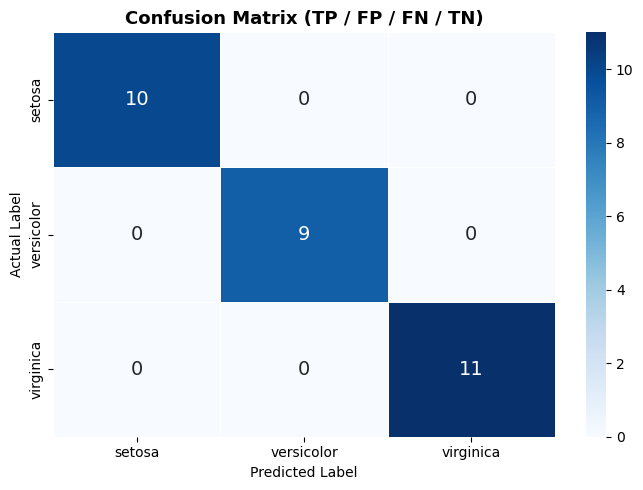

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    linewidths=0.5, annot_kws={'size': 14}
)
plt.title('Confusion Matrix (TP / FP / FN / TN)', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

---
## 🗺️ Bonus — Decision Boundary Visualisation

See how KNN draws the boundary between the 3 species.

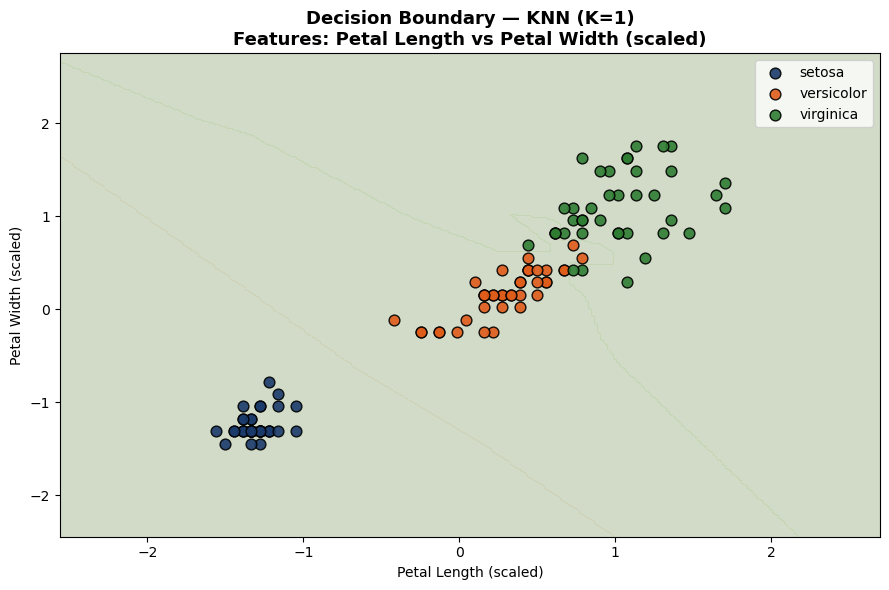

In [15]:
# Use only 2 features (petal length & width) for 2D plotting
X2_train = X_train_scaled[:, 2:4]
X2_test  = X_test_scaled[:, 2:4]

model2d = KNeighborsClassifier(n_neighbors=optimal_k)
model2d.fit(X2_train, y_train)

# Create mesh grid
h = 0.02
x_min, x_max = X2_train[:, 0].min() - 1, X2_train[:, 0].max() + 1
y_min, y_max = X2_train[:, 1].min() - 1, X2_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = model2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
bg_colors     = ['#aec6e8', '#f4c6a0', '#a8d8a8']
point_colors  = ['#1a3a6b', '#e05c1a', '#2e7d32']

plt.figure(figsize=(9, 6))
for i, c in enumerate(bg_colors):
    plt.contourf(xx, yy, Z == i, alpha=0.35, colors=[c])

for i, (name, pc) in enumerate(zip(iris.target_names, point_colors)):
    mask = y_train == i
    plt.scatter(X2_train[mask, 0], X2_train[mask, 1],
                color=pc, label=name, edgecolors='k', s=60, alpha=0.9)

plt.title(f'Decision Boundary — KNN (K={optimal_k})\nFeatures: Petal Length vs Petal Width (scaled)',
          fontsize=13, fontweight='bold')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🎯 Try it yourself — Predict a new flower!

In [16]:
# Change these values and re-run the cell!
sepal_length = 5.1   # cm
sepal_width  = 3.5   # cm
petal_length = 1.4   # cm
petal_width  = 0.2   # cm

new_flower = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)[0]
proba = model.predict_proba(new_flower_scaled)[0]

print(f'🌸 Input : Sepal {sepal_length}x{sepal_width} cm | Petal {petal_length}x{petal_width} cm')
print(f'🤖 Prediction : {iris.target_names[prediction].upper()}')
print()
print('Confidence:')
for name, p in zip(iris.target_names, proba):
    bar = '█' * int(p * 30)
    print(f'  {name:12s} {bar} {p*100:.1f}%')

🌸 Input : Sepal 5.1x3.5 cm | Petal 1.4x0.2 cm
🤖 Prediction : SETOSA

Confidence:
  setosa       ██████████████████████████████ 100.0%
  versicolor    0.0%
  virginica     0.0%


---
## ✅ Summary

I have completed the full **Project 2 Pipeline**:

| Step | Action | Tool |
|------|--------|------|
| 1 | Loaded Iris dataset | `sklearn.datasets` |
| 2 | Explored & visualised | `pandas`, `matplotlib` |
| 3 | Split 80/20 | `train_test_split` |
| 4 | Scaled features | `StandardScaler` |
| 5 | Found optimal K | Elbow Method |
| 6 | Trained KNN model | `KNeighborsClassifier` |
| 7 | Validated results | Confusion Matrix, F1 Score |

---
